In [ ]:
# use holodeck environment

In [ ]:
# making sure the notebook is run from the right directory, as lots of paths are relative to the root directory
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[0]

if not (PROJECT_ROOT / 'holodeck_output_lib_gp_mcmc').exists():
    raise RuntimeError("Please run Jupyter from the notebooks_and_files_for_final_results directory")


In [2]:
# copied from /home/sti50/neural_network/neural_network_probablistic_output.ipynb

In [1]:
# loading data from hdf files
import h5py
import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
import tensorflow_probability as tfp
tfpl = tfp.layers
tfd = tfp.distributions
import os
from pathlib import Path

2026-02-27 12:39:36.090354: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-27 12:39:36.136778: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-02-27 12:39:36.136839: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-02-27 12:39:36.138220: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-02-27 12:39:36.146151: I tensorflow/core/platform/cpu_feature_guar

# SIDM model

# To train and save the NNs for median and std values 

# trying to do median and std values separately

### preparing training dataset

# TAKE LOG10 FIRST AND THEN MEDIAN AND STD

In [ ]:
# hdf5 file path

nsamples = 8000
hdf5_file_path = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/SIDM_Astro_Uniform_Extended_Version2_n{nsamples}_r2000_f5/library/sam-library.hdf5'


with h5py.File(hdf5_file_path, 'r') as f:
    gwb_data = f['gwb'][:] # (nsamples, 5, 2000)
    param_space = f['sample_params'][:] # (nsamples, 6)



In [5]:

####### TAKING LOG10 FIRST AND THEN MEDIAN AND STD ###
######################################################
epsilon = 1e-20 # to avoid log(0)
log10_hc2 = 2 * np.log10(gwb_data + epsilon)
median_log10_hc2 = np.median(log10_hc2, axis=-1)
std_log10_hc2 = np.std(log10_hc2, axis=-1)
r_train = gwb_data.shape[-1]
######################################################

X_train = param_space.copy() # (8000, 6)
m = X_train.shape[0] # 8000
nx = X_train.shape[1] # 6

# for normalizing inputs
mu_x = 1/m * np.sum(X_train, axis=0, keepdims=True)
std_x = np.sqrt(1/m * np.sum((X_train - mu_x)**2, axis=0, keepdims=True))
X_train = (X_train - mu_x) / std_x
print(f'shape of training input: {X_train.shape}')

# preparing training output
Y_train_median_unnormalized = median_log10_hc2.copy()
Y_train_std_unnormalized = std_log10_hc2.copy()
ny = Y_train_median_unnormalized.shape[1] # 5 (number of frequency bins)
Y_train_median_unc_unnormalized = Y_train_std_unnormalized / np.sqrt(r_train)
Y_train_std_unc_unnormalized = Y_train_std_unnormalized / np.sqrt(2*(r_train-1))

# normalizing outputs
mu_y_median = 1/m * np.sum(Y_train_median_unnormalized, axis=0, keepdims=True)
std_y_median = np.sqrt(1/m * np.sum((Y_train_median_unnormalized - mu_y_median)**2, axis=0, keepdims=True))

mu_y_std = 1/m * np.sum(Y_train_std_unnormalized, axis=0, keepdims=True)
std_y_std = np.sqrt(1/m * np.sum((Y_train_std_unnormalized - mu_y_std)**2, axis=0, keepdims=True))

Y_train_median = (Y_train_median_unnormalized - mu_y_median) / std_y_median
Y_train_median_unc = Y_train_median_unc_unnormalized / std_y_median # no subtraction while normalizing error

Y_train_std = Y_train_std_unnormalized / std_y_std # no subtraction while normalizing error
Y_train_std_unc = Y_train_std_unc_unnormalized / std_y_std # no subtraction while normalizing error
# Y_train_std = Y_train_std_unnormalized

Y_train_combined_median = np.concatenate(
    [Y_train_median, Y_train_median_unc],
    axis=1
)  # (8000, 10)

Y_train_combined_std = np.concatenate(
    [Y_train_std, Y_train_std_unc],
    axis=1
)  # (8000, 10)

print(f'shape of training output: {Y_train_median.shape}')

normalization_params = {}
    
normalization_params["mu_x"] = mu_x
normalization_params["std_x"] = std_x
normalization_params["mu_y_median"] = mu_y_median
normalization_params["std_y_median"] = std_y_median
normalization_params["std_y_std"] = std_y_std



shape of training input: (8000, 6)
shape of training output: (8000, 5)


In [ ]:
test_samples = 4000
hdf5_file_path_test = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/SIDM_Astro_Uniform_Extended_Version2_n{test_samples}_r2000_f5/library/sam-library.hdf5'

with h5py.File(hdf5_file_path_test, 'r') as f:
    param_space_test = f['sample_params'][:]
    
# taking log10 because our median values are of order 1e-14, 1e-15 and std ~ 1e-16

# epsilon = 1e-20 # to avoid log(0)
# gwb_median_log_test = np.log10(gwb_median_test + epsilon)
# gwb_std_log_test = np.log10(gwb_std_test + epsilon)


####### TAKING LOG10 FIRST AND THEN MEDIAN AND STD ###
######################################################
with h5py.File(hdf5_file_path_test, 'r') as f:
    gwb_data_test = f['gwb'][:] # (8000, 5, 2000)
epsilon = 1e-20 # to avoid log(0)
log10_hc2_test = 2 * np.log10(gwb_data_test + epsilon)
median_log10_hc2_test = np.median(log10_hc2_test, axis=-1)
std_log10_hc2_test = np.std(log10_hc2_test, axis=-1)
r_test = gwb_data_test.shape[-1]
#######################################################

# taking 50% of 5000 for validation and test resp
val_end = param_space_test.shape[0]//2 # 2500

# preparing input val and test
X_val = param_space_test.copy()[:val_end, :] # (2500, 6)
X_test = param_space_test.copy()[val_end:, :] # (2500, 6)

X_val = (X_val - mu_x) / std_x # (2500, 6)
X_test = (X_test - mu_x) / std_x # (2500, 6)

print(f'shape of validation and test input: {X_val.shape}')

# preparing output val and test
## median of gwb
Y_val_median_unnormalized = median_log10_hc2_test.copy()[:val_end, :] # (2500, 5)
Y_test_median_unnormalized = median_log10_hc2_test.copy()[val_end:, :] # (2500, 5)

Y_val_median = (Y_val_median_unnormalized - mu_y_median) / std_y_median # (2500, 5) # using same mu and std from training
Y_test_median = (Y_test_median_unnormalized - mu_y_median) / std_y_median # (2500, 5)

# std of gwb
Y_val_std_unnormalized = std_log10_hc2_test.copy()[:val_end, :] # (2500, 5)
Y_test_std_unnormalized = std_log10_hc2_test.copy()[val_end:, :] # (2500, 5)

Y_val_median_unc_unnormalized = Y_val_std_unnormalized / np.sqrt(r_test)
Y_val_std_unc_unnormalized = Y_val_std_unnormalized / np.sqrt(2*(r_test-1))
Y_val_median_unc = Y_val_median_unc_unnormalized / std_y_median # no subtraction while normalizing error
Y_val_std_unc = Y_val_std_unc_unnormalized / std_y_std # no subtraction while normalizing error

Y_test_median_unc_unnormalized = Y_test_std_unnormalized / np.sqrt(r_test)
Y_test_std_unc_unnormalized = Y_test_std_unnormalized / np.sqrt(2*(r_test-1))
Y_test_median_unc = Y_test_median_unc_unnormalized / std_y_median # no subtraction while normalizing error
Y_test_std_unc = Y_test_std_unc_unnormalized / std_y_std # no subtraction while normalizing error

# Y_val_std = Y_val_std_unnormalized
# Y_test_std = Y_test_std_unnormalized

Y_val_std = Y_val_std_unnormalized / std_y_std # (2500, 5) # using same mu and std from training
Y_test_std = Y_test_std_unnormalized / std_y_std # (2500, 5)

Y_val_combined_median = np.concatenate(
    [Y_val_median, Y_val_median_unc],
    axis=1
)  # (8000, 10)

Y_val_combined_std = np.concatenate(
    [Y_val_std, Y_val_std_unc],
    axis=1
)  # (8000, 10)

Y_test_combined_median = np.concatenate(
    [Y_test_median, Y_test_median_unc],
    axis=1
)  # (8000, 10)

Y_test_combined_std = np.concatenate(
    [Y_test_std, Y_test_std_unc],
    axis=1
)  # (8000, 10)


print(f'shape of validation and test output: {Y_val_median.shape}')

shape of validation and test input: (2000, 6)
shape of validation and test output: (2000, 5)


In [7]:
# building the nn

from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dense, BatchNormalization, Activation, Dropout

import tensorflow as tf
import tensorflow_probability as tfp

tfd = tfp.distributions
tfpl = tfp.layers


# to report in the paper

In [8]:
import platform
import multiprocessing
import tensorflow as tf

print("Processor:", platform.processor())
print("CPU count:", multiprocessing.cpu_count())
print("TensorFlow version:", tf.__version__)


Processor: AMD EPYC-Milan Processor
CPU count: 200
TensorFlow version: 2.15.1


In [9]:
# with uncertainties
def nll_with_obs_uncertainty(y_true, y_pred):
    """
    y_true[..., :5]  -> normalized target
    y_true[..., 5:]  -> normalized observational uncertainty
    """
    y = y_true[..., :5]
    y_err = y_true[..., 5:]

    total_scale = tf.sqrt(
        tf.square(y_pred.scale) + tf.square(y_err)
    )

    dist = tfd.Normal(
        loc=y_pred.loc,
        scale=total_scale
    )

    return -tf.reduce_mean(dist.log_prob(y))


In [10]:

lambd = 0.0
layer1_depth = 16
layer2_depth = 32
layer3_depth = 16
n_epochs = 1000
loss_function = 'negative log likelihood- def nll(y_true, y_pred):return -y_pred.log_prob(y_true)'

model_median = tf.keras.Sequential([
    tf.keras.layers.Dense(
        layer1_depth, activation='relu', input_shape=(6,),
        kernel_regularizer=tf.keras.regularizers.l2(lambd)
    ),
    tf.keras.layers.Dense(
        layer2_depth, activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(lambd)
    ),
    tf.keras.layers.Dense(
        layer3_depth, activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(lambd)
    ),
    tf.keras.layers.Dense(10),  # 5 means + 5 stds
    tfpl.DistributionLambda(
        lambda t: tfd.Normal(
            loc=t[..., :5],
            scale=1e-3 + tf.nn.softplus(t[..., 5:])
        )
    )
])


model_median.compile(
    optimizer='adam',
    loss=nll_with_obs_uncertainty
)

early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=100,              # adjust if needed
    restore_best_weights=True, # THIS is the important part
    verbose=1
)

2026-02-23 23:52:25.132346: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


In [11]:
import time

start_time = time.time()

history_median = model_median.fit(
    X_train, Y_train_combined_median,
    validation_data=(X_val, Y_val_combined_median),
    epochs=n_epochs,
    # batch_size=32,
    verbose=1,
    callbacks=[early_stop_cb],
)

end_time = time.time()

total_time = end_time - start_time
print(f"Total training time: {total_time:.2f} seconds")
print(f"Time per epoch: {total_time/n_epochs:.2f} seconds")


Epoch 1/1000
250/250 [==============================] - 3s 5ms/step - loss: 0.8994 - val_loss: 0.2222
Epoch 2/1000
250/250 [==============================] - 1s 3ms/step - loss: 0.0126 - val_loss: -0.1538
Epoch 3/1000
250/250 [==============================] - 1s 3ms/step - loss: -0.2135 - val_loss: -0.3221
Epoch 4/1000
250/250 [==============================] - 1s 3ms/step - loss: -0.3692 - val_loss: -0.4538
Epoch 5/1000
250/250 [==============================] - 1s 3ms/step - loss: -0.4687 - val_loss: -0.5472
Epoch 6/1000
250/250 [==============================] - 1s 5ms/step - loss: -0.5327 - val_loss: -0.5839
Epoch 7/1000
250/250 [==============================] - 1s 3ms/step - loss: -0.6204 - val_loss: -0.6366
Epoch 8/1000
250/250 [==============================] - 1s 3ms/step - loss: -0.6999 - val_loss: -0.6815
Epoch 9/1000
250/250 [==============================] - 1s 4ms/step - loss: -0.7655 - val_loss: -0.7904
Epoch 10/1000
250/250 [==============================] - 1s 3ms/ste

In [12]:
import numpy as np

val_losses = history_median.history['val_loss']
best_epoch = np.argmin(val_losses) + 1
best_val_loss = np.min(val_losses)

print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Best epoch: 963
Best validation loss: -2.6126856803894043


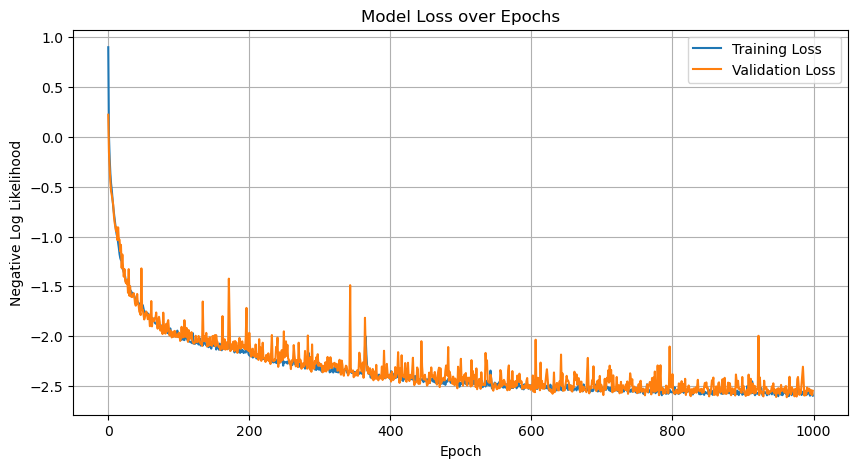

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history_median.history['loss'], label='Training Loss')
plt.plot(history_median.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Negative Log Likelihood')
plt.title('Model Loss over Epochs')
plt.legend()
plt.grid(True)
# Optional: adjust y-limit based on your loss scale
# plt.ylim([0, some_max])
plt.show()


In [14]:
# training metrics
train_loss = history_median.history['loss']

# validation metrics
val_loss = history_median.history['val_loss']

# last values (after final epoch)
print("Final Train loss (negative log likeihood): {:.4f}".format(train_loss[-1]))
print("Final Val loss: {:.4f}".format(val_loss[-1]))

Final Train loss (negative log likeihood): -2.5969
Final Val loss: -2.5481


In [15]:
test_loss = model_median.evaluate(X_test, Y_test_combined_median, verbose=1)

print("Test loss: {:.4f}".format(test_loss))

63/63 [==============================] - 0s 876us/step - loss: -2.5381
Test loss: -2.5381


In [16]:
nsamples

8000

In [ ]:
architecture = {
    "training samples": nsamples,
    "activation function": "ReLU",
    "layer_1": layer1_depth,
    "layer_2": layer2_depth,
    "layer_3": layer3_depth,
    "L2 regularization lambda (applied to all layers)": lambd,
    "epochs": n_epochs,
    "Best epoch:": best_epoch,
    "training_set_path": hdf5_file_path,
    "loss_function": "nll_with_obs_uncertainty",
    "loss_source": ".../nn_training_output/losses.py",
    "loss_description": (
        "Gaussian negative log-likelihood with observational uncertainty "
        "added in quadrature to predictive scale"
    ),
    "versions": {
        "tensorflow": tf.__version__,
        "tensorflow_probability": tfp.__version__,
    }
}
save_dir = Path(hdf5_file_path).parents[1] / 'nn_training_output'
os.makedirs(save_dir, exist_ok=True)


np.savetxt(os.path.join(save_dir,'nn_architecture_median.txt'), 
           np.array(list(architecture.items())), fmt='%s')
model_median.save(os.path.join(save_dir, 'nn_model_median.keras'))
np.savez(os.path.join(save_dir, 'normalization_params.npz'),
         **normalization_params)

/home/sti50/holodeck_shreyas_environment/lib/python3.9/site-packages/keras/src/saving/serialization_lib.py:159: UserWarning: The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized:         lambda t: tfd.Normal(
            loc=t[..., :5],
            scale=1e-3 + tf.nn.softplus(t[..., 5:])
        )

  config_arr = [serialize_keras_object(x) for x in obj]


# training for std

In [18]:
lambd = 0.0
layer1_depth = 16
layer2_depth = 32
layer3_depth = 16
n_epochs = 1000
loss_function = 'negative log likelihood- def nll(y_true, y_pred):return -y_pred.log_prob(y_true)'


model_std = tf.keras.Sequential([
    tf.keras.layers.Dense(
        layer1_depth, activation='relu', input_shape=(6,),
        kernel_regularizer=tf.keras.regularizers.l2(lambd)
    ),
    tf.keras.layers.Dense(
        layer2_depth, activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(lambd)
    ),
    tf.keras.layers.Dense(
        layer3_depth, activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(lambd)
    ),
    tf.keras.layers.Dense(10),  # 5 means + 5 stds
    tfpl.DistributionLambda(
        lambda t: tfd.Normal(
            loc=t[..., :5],
            scale=1e-3 + tf.nn.softplus(t[..., 5:])
        )
    )
])


# def nll(y_true, y_pred):
#     return -y_pred.log_prob(y_true)

# model_std.compile(
#     optimizer='adam',
#     loss=nll
# )

model_std.compile(
    optimizer='adam',
    loss=nll_with_obs_uncertainty
)

early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=100,              # adjust if needed
    restore_best_weights=True, # THIS is the important part
    verbose=1
)

In [19]:
import time

start_time = time.time()

history_std = model_std.fit(
    X_train, Y_train_combined_std,
    validation_data=(X_val, Y_val_combined_std),
    epochs=n_epochs,
    # batch_size=32,
    verbose=1,
    callbacks=[early_stop_cb],
)

end_time = time.time()

total_time = end_time - start_time
print(f"Total training time: {total_time:.2f} seconds")
print(f"Time per epoch: {total_time/n_epochs:.2f} seconds")

Epoch 1/1000
250/250 [==============================] - 1s 2ms/step - loss: 1.2276 - val_loss: 0.6285
Epoch 2/1000
250/250 [==============================] - 0s 1ms/step - loss: 0.2934 - val_loss: 0.0713
Epoch 3/1000
250/250 [==============================] - 0s 1ms/step - loss: -0.0228 - val_loss: -0.1508
Epoch 4/1000
250/250 [==============================] - 0s 1ms/step - loss: -0.1977 - val_loss: -0.2720
Epoch 5/1000
250/250 [==============================] - 0s 2ms/step - loss: -0.3299 - val_loss: -0.4175
Epoch 6/1000
250/250 [==============================] - 0s 1ms/step - loss: -0.4184 - val_loss: -0.4609
Epoch 7/1000
250/250 [==============================] - 0s 1ms/step - loss: -0.5114 - val_loss: -0.5673
Epoch 8/1000
250/250 [==============================] - 0s 1ms/step - loss: -0.5701 - val_loss: -0.6407
Epoch 9/1000
250/250 [==============================] - 0s 1ms/step - loss: -0.6162 - val_loss: -0.6661
Epoch 10/1000
250/250 [==============================] - 0s 1ms/step

In [20]:
import numpy as np

val_losses = history_std.history['val_loss']
best_epoch = np.argmin(val_losses) + 1
best_val_loss = np.min(val_losses)

print("Best epoch:", best_epoch)
print("Best validation loss:", best_val_loss)

Best epoch: 737
Best validation loss: -1.7900763750076294


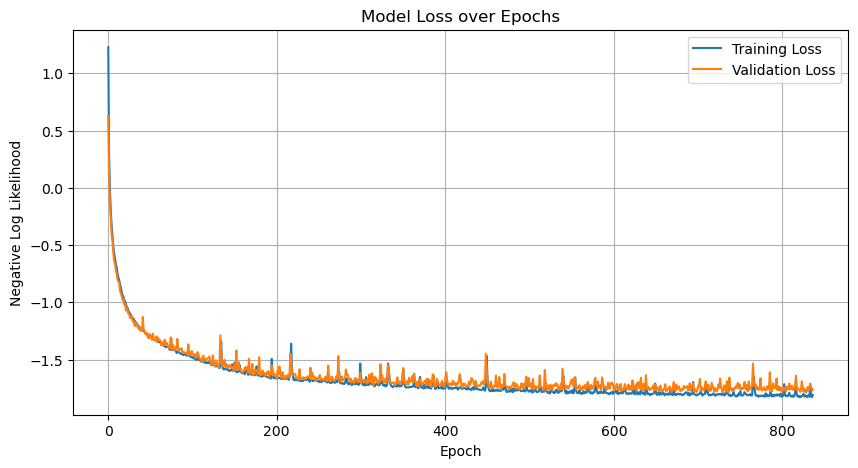

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history_std.history['loss'], label='Training Loss')
plt.plot(history_std.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Negative Log Likelihood')
plt.title('Model Loss over Epochs')
plt.legend()
plt.grid(True)
# Optional: adjust y-limit based on your loss scale
# plt.ylim([0, some_max])
plt.show()


In [22]:
# training metrics
train_loss = history_std.history['loss']

# validation metrics
val_loss = history_std.history['val_loss']

# last values (after final epoch)
print("Final Train loss (negative log likeihood): {:.4f}".format(train_loss[-1]))
print("Final Val loss: {:.4f}".format(val_loss[-1]))

test_loss = model_std.evaluate(X_test, Y_test_combined_std, verbose=1)

print("Test loss: {:.4f}".format(test_loss))

Final Train loss (negative log likeihood): -1.8092
Final Val loss: -1.7672
63/63 [==============================] - 0s 954us/step - loss: -1.8032
Test loss: -1.8032


In [ ]:
architecture = {
    "training samples": nsamples,
    "activation function": "ReLU",
    "layer_1": layer1_depth,
    "layer_2": layer2_depth,
    "layer_3": layer3_depth,
    "L2 regularization lambda (applied to all layers)": lambd,
    "epochs": n_epochs,
    "Best epoch:": best_epoch,
    "training_set_path": hdf5_file_path,
    "loss_function": "nll_with_obs_uncertainty",
    "loss_source": ".../nn_training_output/losses.py",
    "loss_description": (
        "Gaussian negative log-likelihood with observational uncertainty "
        "added in quadrature to predictive scale"
    ),
    "versions": {
        "tensorflow": tf.__version__,
        "tensorflow_probability": tfp.__version__,
    }
}

save_dir = Path(hdf5_file_path).parents[1] / 'nn_training_output'
os.makedirs(save_dir, exist_ok=True)


np.savetxt(os.path.join(save_dir,'nn_architecture_std.txt'), 
           np.array(list(architecture.items())), fmt='%s')
model_std.save(os.path.join(save_dir, 'nn_model_std.keras'))
np.savez(os.path.join(save_dir, 'normalization_params.npz'),
         **normalization_params)

# training and saving NNs for SIDM is done

# doing the same for phenom model

In [ ]:
# hdf5 file path

nsamples = 2000
hdf5_file_path = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/Phenom_Uniform_n{nsamples}_r2000_f5/library/sam-library.hdf5'


with h5py.File(hdf5_file_path, 'r') as f:
    gwb_data = f['gwb'][:] # (nsamples, 5, 2000)
    param_space = f['sample_params'][:] # (nsamples, 6)


####### TAKING LOG10 FIRST AND THEN MEDIAN AND STD ###
######################################################
epsilon = 1e-20 # to avoid log(0)
log10_hc2 = 2 * np.log10(gwb_data + epsilon)
median_log10_hc2 = np.median(log10_hc2, axis=-1)
std_log10_hc2 = np.std(log10_hc2, axis=-1)
r_train = gwb_data.shape[-1]
######################################################

X_train = param_space.copy() # (8000, 6)
m = X_train.shape[0] # 8000
nx = X_train.shape[1] # 6

# for normalizing inputs
mu_x = 1/m * np.sum(X_train, axis=0, keepdims=True)
std_x = np.sqrt(1/m * np.sum((X_train - mu_x)**2, axis=0, keepdims=True))
X_train = (X_train - mu_x) / std_x
print(f'shape of training input: {X_train.shape}')

# preparing training output
Y_train_median_unnormalized = median_log10_hc2.copy()
Y_train_std_unnormalized = std_log10_hc2.copy()
ny = Y_train_median_unnormalized.shape[1] # 5 (number of frequency bins)
Y_train_median_unc_unnormalized = Y_train_std_unnormalized / np.sqrt(r_train)
Y_train_std_unc_unnormalized = Y_train_std_unnormalized / np.sqrt(2*(r_train-1))

# normalizing outputs
mu_y_median = 1/m * np.sum(Y_train_median_unnormalized, axis=0, keepdims=True)
std_y_median = np.sqrt(1/m * np.sum((Y_train_median_unnormalized - mu_y_median)**2, axis=0, keepdims=True))

mu_y_std = 1/m * np.sum(Y_train_std_unnormalized, axis=0, keepdims=True)
std_y_std = np.sqrt(1/m * np.sum((Y_train_std_unnormalized - mu_y_std)**2, axis=0, keepdims=True))

Y_train_median = (Y_train_median_unnormalized - mu_y_median) / std_y_median
Y_train_median_unc = Y_train_median_unc_unnormalized / std_y_median # no subtraction while normalizing error

Y_train_std = Y_train_std_unnormalized / std_y_std # no subtraction while normalizing error
Y_train_std_unc = Y_train_std_unc_unnormalized / std_y_std # no subtraction while normalizing error
# Y_train_std = Y_train_std_unnormalized

Y_train_combined_median = np.concatenate(
    [Y_train_median, Y_train_median_unc],
    axis=1
)  # (8000, 10)

Y_train_combined_std = np.concatenate(
    [Y_train_std, Y_train_std_unc],
    axis=1
)  # (8000, 10)

print(f'shape of training output: {Y_train_median.shape}')

normalization_params = {}
    
normalization_params["mu_x"] = mu_x
normalization_params["std_x"] = std_x
normalization_params["mu_y_median"] = mu_y_median
normalization_params["std_y_median"] = std_y_median
normalization_params["std_y_std"] = std_y_std


test_samples = 2000
# hdf5 file path for test library
hdf5_file_path_test = f'{PROJECT_ROOT}/holodeck_output_lib_gp_mcmc/Phenom_Uniform_n{nsamples}_r2000_f5/library2_gp_nn_accuracy/sam-library.hdf5'

with h5py.File(hdf5_file_path_test, 'r') as f:
    param_space_test = f['sample_params'][:]
    
# taking log10 because our median values are of order 1e-14, 1e-15 and std ~ 1e-16

# epsilon = 1e-20 # to avoid log(0)
# gwb_median_log_test = np.log10(gwb_median_test + epsilon)
# gwb_std_log_test = np.log10(gwb_std_test + epsilon)


####### TAKING LOG10 FIRST AND THEN MEDIAN AND STD ###
######################################################
with h5py.File(hdf5_file_path_test, 'r') as f:
    gwb_data_test = f['gwb'][:] # (8000, 5, 2000)
epsilon = 1e-20 # to avoid log(0)
log10_hc2_test = 2 * np.log10(gwb_data_test + epsilon)
median_log10_hc2_test = np.median(log10_hc2_test, axis=-1)
std_log10_hc2_test = np.std(log10_hc2_test, axis=-1)
r_test = gwb_data_test.shape[-1]
#######################################################

# taking 50% of 5000 for validation and test resp
val_end = param_space_test.shape[0]//2 # 2500

# preparing input val and test
X_val = param_space_test.copy()[:val_end, :] # (2500, 6)
X_test = param_space_test.copy()[val_end:, :] # (2500, 6)

X_val = (X_val - mu_x) / std_x # (2500, 6)
X_test = (X_test - mu_x) / std_x # (2500, 6)

print(f'shape of validation and test input: {X_val.shape}')

# preparing output val and test
## median of gwb
Y_val_median_unnormalized = median_log10_hc2_test.copy()[:val_end, :] # (2500, 5)
Y_test_median_unnormalized = median_log10_hc2_test.copy()[val_end:, :] # (2500, 5)

Y_val_median = (Y_val_median_unnormalized - mu_y_median) / std_y_median # (2500, 5) # using same mu and std from training
Y_test_median = (Y_test_median_unnormalized - mu_y_median) / std_y_median # (2500, 5)

# std of gwb
Y_val_std_unnormalized = std_log10_hc2_test.copy()[:val_end, :] # (2500, 5)
Y_test_std_unnormalized = std_log10_hc2_test.copy()[val_end:, :] # (2500, 5)

Y_val_median_unc_unnormalized = Y_val_std_unnormalized / np.sqrt(r_test)
Y_val_std_unc_unnormalized = Y_val_std_unnormalized / np.sqrt(2*(r_test-1))
Y_val_median_unc = Y_val_median_unc_unnormalized / std_y_median # no subtraction while normalizing error
Y_val_std_unc = Y_val_std_unc_unnormalized / std_y_std # no subtraction while normalizing error

Y_test_median_unc_unnormalized = Y_test_std_unnormalized / np.sqrt(r_test)
Y_test_std_unc_unnormalized = Y_test_std_unnormalized / np.sqrt(2*(r_test-1))
Y_test_median_unc = Y_test_median_unc_unnormalized / std_y_median # no subtraction while normalizing error
Y_test_std_unc = Y_test_std_unc_unnormalized / std_y_std # no subtraction while normalizing error

# Y_val_std = Y_val_std_unnormalized
# Y_test_std = Y_test_std_unnormalized

Y_val_std = Y_val_std_unnormalized / std_y_std # (2500, 5) # using same mu and std from training
Y_test_std = Y_test_std_unnormalized / std_y_std # (2500, 5)

Y_val_combined_median = np.concatenate(
    [Y_val_median, Y_val_median_unc],
    axis=1
)  # (8000, 10)

Y_val_combined_std = np.concatenate(
    [Y_val_std, Y_val_std_unc],
    axis=1
)  # (8000, 10)

Y_test_combined_median = np.concatenate(
    [Y_test_median, Y_test_median_unc],
    axis=1
)  # (8000, 10)

Y_test_combined_std = np.concatenate(
    [Y_test_std, Y_test_std_unc],
    axis=1
)  # (8000, 10)


print(f'shape of validation and test output: {Y_val_median.shape}')

shape of training input: (2000, 6)
shape of training output: (2000, 5)
shape of validation and test input: (1000, 6)
shape of validation and test output: (1000, 5)


In [3]:
# building the nn

from tensorflow.keras import regularizers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dense, BatchNormalization, Activation, Dropout

import tensorflow as tf
import tensorflow_probability as tfp

tfd = tfp.distributions
tfpl = tfp.layers

# with uncertainties
def nll_with_obs_uncertainty(y_true, y_pred):
    """
    y_true[..., :5]  -> normalized target
    y_true[..., 5:]  -> normalized observational uncertainty
    """
    y = y_true[..., :5]
    y_err = y_true[..., 5:]

    total_scale = tf.sqrt(
        tf.square(y_pred.scale) + tf.square(y_err)
    )

    dist = tfd.Normal(
        loc=y_pred.loc,
        scale=total_scale
    )

    return -tf.reduce_mean(dist.log_prob(y))


In [4]:
import platform
import multiprocessing
import tensorflow as tf

print("Processor:", platform.processor())
print("CPU count:", multiprocessing.cpu_count())
print("TensorFlow version:", tf.__version__)


Processor: AMD EPYC-Milan Processor
CPU count: 200
TensorFlow version: 2.15.1


Epoch 1/1000


2026-02-27 12:40:35.591737: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:274] failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


63/63 [==============================] - 1s 5ms/step - loss: 1.4635 - val_loss: 1.2573
Epoch 2/1000
63/63 [==============================] - 0s 2ms/step - loss: 1.2387 - val_loss: 1.1023
Epoch 3/1000
63/63 [==============================] - 0s 2ms/step - loss: 1.0948 - val_loss: 1.0029
Epoch 4/1000
63/63 [==============================] - 0s 2ms/step - loss: 0.9975 - val_loss: 0.9174
Epoch 5/1000
63/63 [==============================] - 0s 2ms/step - loss: 0.9186 - val_loss: 0.8497
Epoch 6/1000
63/63 [==============================] - 0s 2ms/step - loss: 0.8476 - val_loss: 0.7694
Epoch 7/1000
63/63 [==============================] - 0s 2ms/step - loss: 0.7684 - val_loss: 0.6813
Epoch 8/1000
63/63 [==============================] - 0s 2ms/step - loss: 0.6854 - val_loss: 0.6030
Epoch 9/1000
63/63 [==============================] - 0s 2ms/step - loss: 0.5946 - val_loss: 0.5292
Epoch 10/1000
63/63 [==============================] - 0s 2ms/step - loss: 0.4889 - val_loss: 0.4133
Epoch 11/100

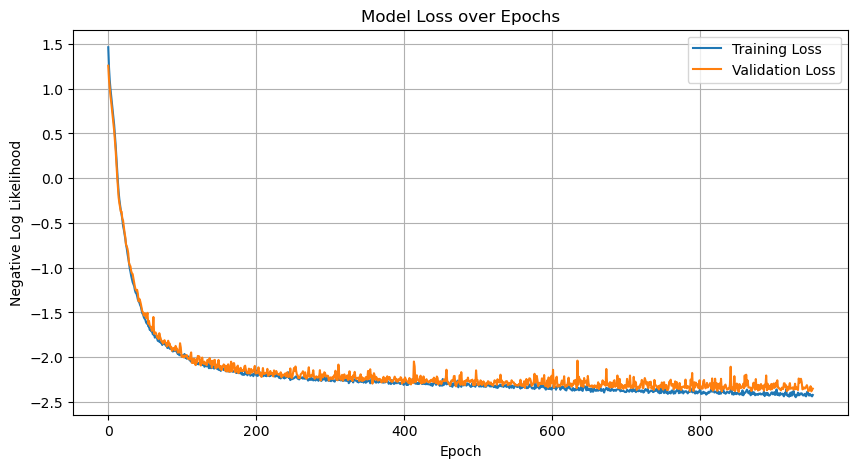

Best epoch: 853
Best validation loss: -2.39
Best training loss: -2.45
32/32 [==============================] - 0s 900us/step - loss: -2.3616
Test loss: -2.36


In [5]:

lambd = 0.001
layer1_depth = 8
layer2_depth = 16
layer3_depth = 8
n_epochs = 1000
loss_function = 'negative log likelihood- def nll(y_true, y_pred):return -y_pred.log_prob(y_true)'

model_median = tf.keras.Sequential([
    tf.keras.layers.Dense(
        layer1_depth, activation='relu', input_shape=(6,),
        kernel_regularizer=tf.keras.regularizers.l2(lambd)
    ),
    tf.keras.layers.Dense(
        layer2_depth, activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(lambd)
    ),
    tf.keras.layers.Dense(
        layer3_depth, activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(lambd)
    ),
    tf.keras.layers.Dense(10),  # 5 means + 5 stds
    tfpl.DistributionLambda(
        lambda t: tfd.Normal(
            loc=t[..., :5],
            scale=1e-3 + tf.nn.softplus(t[..., 5:])
        )
    )
])


model_median.compile(
    optimizer='adam',
    loss=nll_with_obs_uncertainty
)

early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=100,              # adjust if needed
    restore_best_weights=True, # THIS is the important part
    verbose=1
)

import time

start_time = time.time()

history_median = model_median.fit(
    X_train, Y_train_combined_median,
    validation_data=(X_val, Y_val_combined_median),
    epochs=n_epochs,
    # batch_size=32,
    verbose=1,
    callbacks=[early_stop_cb],
)

end_time = time.time()

total_time = end_time - start_time
print(f"Total training time: {total_time:.2f} seconds")
print(f"Time per epoch: {total_time/n_epochs:.2f} seconds")

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history_median.history['loss'], label='Training Loss')
plt.plot(history_median.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Negative Log Likelihood')
plt.title('Model Loss over Epochs')
plt.legend()
plt.grid(True)
# Optional: adjust y-limit based on your loss scale
# plt.ylim([0, some_max])
plt.show()


# validation metrics
import numpy as np

val_losses = history_median.history['val_loss']
best_epoch = np.argmin(val_losses) + 1
best_val_loss = np.min(val_losses)

train_losses = history_median.history['loss']
best_train_loss = np.min(train_losses)

print("Best epoch:", best_epoch)
print("Best validation loss: {:.2f}".format(best_val_loss))
print("Best training loss: {:.2f}".format(best_train_loss))

test_loss = model_median.evaluate(X_test, Y_test_combined_median, verbose=1)

print("Test loss: {:.2f}".format(test_loss))


In [6]:
import numpy as np

val_losses = history_median.history['val_loss']
best_epoch = np.argmin(val_losses) + 1
best_val_loss = np.min(val_losses)

train_losses = history_median.history['loss']
best_train_loss = np.min(train_losses)

print("Best epoch:", best_epoch)
print("Best validation loss: {:.2f}".format(best_val_loss))
print("Best training loss: {:.2f}".format(best_train_loss))

test_loss = model_median.evaluate(X_test, Y_test_combined_median, verbose=1)

print("Test loss: {:.2f}".format(test_loss))

Best epoch: 853
Best validation loss: -2.39
Best training loss: -2.45
32/32 [==============================] - 0s 808us/step - loss: -2.3616
Test loss: -2.36


In [7]:
architecture = {
    "training samples": nsamples,
    "activation function": "ReLU",
    "layer_1": layer1_depth,
    "layer_2": layer2_depth,
    "layer_3": layer3_depth,
    "L2 regularization lambda (applied to all layers)": lambd,
    "epochs": n_epochs,
    "Best epoch:": best_epoch,
    "training_set_path": hdf5_file_path,
    "loss_function": "nll_with_obs_uncertainty",
    "loss_source": ".../nn_training_output/losses.py",
    "loss_description": (
        "Gaussian negative log-likelihood with observational uncertainty "
        "added in quadrature to predictive scale"
    ),
    "versions": {
        "tensorflow": tf.__version__,
        "tensorflow_probability": tfp.__version__,
    }
}
save_dir = Path(hdf5_file_path).parents[1] / 'nn_training_output'
os.makedirs(save_dir, exist_ok=True)


np.savetxt(os.path.join(save_dir,'nn_architecture_median.txt'), 
           np.array(list(architecture.items())), fmt='%s')
model_median.save(os.path.join(save_dir, 'nn_model_median.keras'))
np.savez(os.path.join(save_dir, 'normalization_params.npz'),
         **normalization_params)

/home/sti50/holodeck_shreyas_environment/lib/python3.9/site-packages/keras/src/saving/serialization_lib.py:159: UserWarning: The object being serialized includes a `lambda`. This is unsafe. In order to reload the object, you will have to pass `safe_mode=False` to the loading function. Please avoid using `lambda` in the future, and use named Python functions instead. This is the `lambda` being serialized:         lambda t: tfd.Normal(
            loc=t[..., :5],
            scale=1e-3 + tf.nn.softplus(t[..., 5:])
        )

  config_arr = [serialize_keras_object(x) for x in obj]


Epoch 1/1000
63/63 [==============================] - 1s 9ms/step - loss: 2.7269 - val_loss: 1.8429
Epoch 2/1000
63/63 [==============================] - 0s 2ms/step - loss: 1.6322 - val_loss: 1.2934
Epoch 3/1000
63/63 [==============================] - 0s 2ms/step - loss: 1.2356 - val_loss: 1.0771
Epoch 4/1000
63/63 [==============================] - 0s 2ms/step - loss: 1.0374 - val_loss: 0.9119
Epoch 5/1000
63/63 [==============================] - 0s 2ms/step - loss: 0.8769 - val_loss: 0.7398
Epoch 6/1000
63/63 [==============================] - 0s 2ms/step - loss: 0.7076 - val_loss: 0.5630
Epoch 7/1000
63/63 [==============================] - 0s 2ms/step - loss: 0.5396 - val_loss: 0.4012
Epoch 8/1000
63/63 [==============================] - 0s 2ms/step - loss: 0.3742 - val_loss: 0.2771
Epoch 9/1000
63/63 [==============================] - 0s 2ms/step - loss: 0.2463 - val_loss: 0.1220
Epoch 10/1000
63/63 [==============================] - 0s 2ms/step - loss: 0.1196 - val_loss: 0.0312

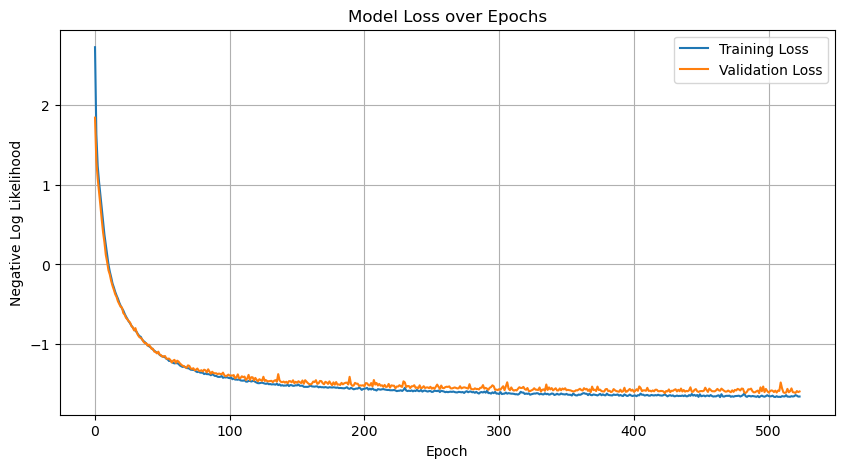

Final Train loss (negative log likeihood): -1.6577
Final Val loss: -1.5944
32/32 [==============================] - 0s 983us/step - loss: -1.6214
Test loss: -1.6214


In [ ]:
lambd = 0.001
layer1_depth = 8
layer2_depth = 16
layer3_depth = 8
n_epochs = 1000
loss_function = 'negative log likelihood- def nll(y_true, y_pred):return -y_pred.log_prob(y_true)'


model_std = tf.keras.Sequential([
    tf.keras.layers.Dense(
        layer1_depth, activation='relu', input_shape=(6,),
        kernel_regularizer=tf.keras.regularizers.l2(lambd)
    ),
    tf.keras.layers.Dense(
        layer2_depth, activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(lambd)
    ),
    tf.keras.layers.Dense(
        layer3_depth, activation='relu',
        kernel_regularizer=tf.keras.regularizers.l2(lambd)
    ),
    tf.keras.layers.Dense(10),  # 5 means + 5 stds
    tfpl.DistributionLambda(
        lambda t: tfd.Normal(
            loc=t[..., :5],
            scale=1e-3 + tf.nn.softplus(t[..., 5:])
        )
    )
])


# def nll(y_true, y_pred):
#     return -y_pred.log_prob(y_true)

# model_std.compile(
#     optimizer='adam',
#     loss=nll
# )

model_std.compile(
    optimizer='adam',
    loss=nll_with_obs_uncertainty
)

early_stop_cb = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    mode="min",
    patience=100,              # adjust if needed
    restore_best_weights=True, # THIS is the important part
    verbose=1
)

import time

start_time = time.time()
history_std = model_std.fit(
    X_train, Y_train_combined_std,
    validation_data=(X_val, Y_val_combined_std),
    epochs=n_epochs,
    # batch_size=32,
    verbose=1,
    callbacks=[early_stop_cb],
)

end_time = time.time()

total_time = end_time - start_time
print(f"Total training time: {total_time:.2f} seconds")
print(f"Time per epoch: {total_time/n_epochs:.2f} seconds")
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(history_std.history['loss'], label='Training Loss')
plt.plot(history_std.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Negative Log Likelihood')
plt.title('Model Loss over Epochs')
plt.legend()
plt.grid(True)
# Optional: adjust y-limit based on your loss scale
# plt.ylim([0, some_max])
plt.show()

# validation metrics
import numpy as np

val_losses = history_std.history['val_loss']
best_epoch = np.argmin(val_losses) + 1
best_val_loss = np.min(val_losses)

train_losses = history_std.history['loss']
best_train_loss = np.min(train_losses)

print("Best epoch:", best_epoch)
print("Best validation loss: {:.2f}".format(best_val_loss))
print("Best training loss: {:.2f}".format(best_train_loss))

test_loss = model_std.evaluate(X_test, Y_test_combined_std, verbose=1)

print("Test loss: {:.2f}".format(test_loss))

In [11]:
import numpy as np

val_losses = history_std.history['val_loss']
best_epoch = np.argmin(val_losses) + 1
best_val_loss = np.min(val_losses)

train_losses = history_std.history['loss']
best_train_loss = np.min(train_losses)

print("Best epoch:", best_epoch)
print("Best validation loss: {:.2f}".format(best_val_loss))
print("Best training loss: {:.2f}".format(best_train_loss))

test_loss = model_std.evaluate(X_test, Y_test_combined_std, verbose=1)

print("Test loss: {:.2f}".format(test_loss))

Best epoch: 424
Best validation loss: -1.62
Best training loss: -1.67
32/32 [==============================] - 0s 1ms/step - loss: -1.6214
Test loss: -1.62


In [ ]:
architecture = {
    "training samples": nsamples,
    "activation function": "ReLU",
    "layer_1": layer1_depth,
    "layer_2": layer2_depth,
    "layer_3": layer3_depth,
    "L2 regularization lambda (applied to all layers)": lambd,
    "epochs": n_epochs,
    "Best epoch:": best_epoch,
    "training_set_path": hdf5_file_path,
    "loss_function": "nll_with_obs_uncertainty",
    "loss_source": ".../nn_training_output/losses.py",
    "loss_description": (
        "Gaussian negative log-likelihood with observational uncertainty "
        "added in quadrature to predictive scale"
    ),
    "versions": {
        "tensorflow": tf.__version__,
        "tensorflow_probability": tfp.__version__,
    }
}

save_dir = Path(hdf5_file_path).parents[1] / 'nn_training_output'
os.makedirs(save_dir, exist_ok=True)


np.savetxt(os.path.join(save_dir,'nn_architecture_std.txt'), 
           np.array(list(architecture.items())), fmt='%s')
model_std.save(os.path.join(save_dir, 'nn_model_std.keras'))
np.savez(os.path.join(save_dir, 'normalization_params.npz'),
         **normalization_params)